In [23]:
import torch
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
import torchvision
import torch.nn as nn
import torchvision.models as models
import numpy as np
from sklearn.linear_model import LogisticRegression                                                                                                                                                   
from sklearn.metrics import accuracy_score   
import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE = 256
BUDGET = 10 # Budget
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Import Dataset

In [15]:

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


### Build Encoder

In [4]:
class ResNet18Encoder(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18Encoder, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()  # Remove maxpool layer for CIFAR-10
        self.resnet.fc = nn.Identity()  # Remove fully connected layer for feature extraction

    def forward(self, x):
        return self.resnet(x)

### Import Encoder Weights

In [5]:
encoder = ResNet18Encoder()
encoder.load_state_dict(torch.load('./simclr_encoder_200ep.pth'))
encoder = encoder.cuda()
encoder.eval()

/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet18Encoder(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
     

### Extract Embeddings

In [6]:
encoder.eval()
embeddings = []
labels = []

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=False, num_workers=2)

with torch.no_grad():
    for images, label in trainloader:                                                                                                   
        images = images.to(device)                                                                                                      
        h = encoder(images)   
        embeddings.append(h.cpu().numpy())
        labels.append(label.numpy())

embeddings = np.vstack(embeddings)
labels = np.hstack(labels)

### Perform Nearest Neighbours for Active Learning

In [7]:
nearest_neighbours = NearestNeighbors(n_neighbors=21)
nearest_neighbours.fit(embeddings)
distances, indices = nearest_neighbours.kneighbors(embeddings)

# slice self distances
distances = distances[:, 1:]
indices = indices[:, 1:]

typicallity = np.mean(distances, axis=1)**-1

### Perform K-Means Clustering on embedding Matrix

In [8]:
kmeans = KMeans(n_clusters=BUDGET, random_state=42)
kmeans.fit(embeddings)
cluster_labels = kmeans.labels_

### Query Typical Examples

In [9]:
selected_indices = []
for cluster in range(BUDGET):
    cluster_indices = np.where(cluster_labels == cluster)[0]
    cluster_typicallity = typicallity[cluster_indices]
    most_typical_index = cluster_indices[np.argmax(cluster_typicallity)]
    selected_indices.append(most_typical_index)
print("Selected indices for labeling:", selected_indices)


Selected indices for labeling: [np.int64(16434), np.int64(32239), np.int64(33063), np.int64(44775), np.int64(32286), np.int64(13523), np.int64(48525), np.int64(49134), np.int64(29916), np.int64(41454)]


### Visualise the Selected Typical Examples

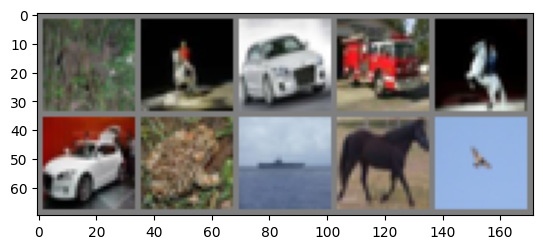

Selected labels: deer horse car truck horse car frog ship horse bird


In [12]:
selected_images = [trainset[i][0] for i in selected_indices]
selected_labels = [classes[labels[i]] for i in selected_indices]                                                                    
                                                                                                                                    
grid = torchvision.utils.make_grid(torch.stack(selected_images), nrow=5)  
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
                                                              
imshow(grid)    
print("Selected labels:", ' '.join(selected_labels))

### Extract Test Set Embeddings

In [16]:
encoder.eval()
test_embeddings = []
test_labels = []

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

with torch.no_grad():
    for images, label in testloader:                                                                                                   
        images = images.to(device)                                                                                                      
        h = encoder(images)   
        test_embeddings.append(h.cpu().numpy())
        test_labels.append(label.numpy())

test_embeddings = np.vstack(test_embeddings)
test_labels = np.hstack(test_labels)

### Evaluate TipyClust Selection

In [22]:
selected_embedding = []
selected_labels = []


for index in selected_indices:
    selected_embedding.append(embeddings[index].reshape(1, -1))
    selected_labels.append(labels[index])

selected_embedding = np.vstack(selected_embedding)
selected_labels = np.hstack(selected_labels)

In [24]:
regressor = LogisticRegression(max_iter=1000)
regressor.fit(selected_embedding, selected_labels)
test_predictions = regressor.predict(test_embeddings)
accuracy = accuracy_score(test_labels, test_predictions)

In [25]:
print(f"Test Accuracy with {BUDGET} selected samples: {accuracy:.4f}")

Test Accuracy with 10 selected samples: 0.4357


In [30]:
random_accuracies = []
for i in range(30):
    regressor = LogisticRegression(max_iter=1000)
    random_indices = np.random.RandomState(i).choice(len(embeddings), size=BUDGET, replace=False)
    random_embedding = embeddings[random_indices]
    random_labels = labels[random_indices]
    
    regressor.fit(random_embedding, random_labels)
    random_predictions = regressor.predict(test_embeddings)
    random_accuracy = accuracy_score(test_labels, random_predictions)
    random_accuracies.append(random_accuracy)

In [31]:
print(f"Test Accuracy with {BUDGET} selected samples: {accuracy:.4f}")
print(f"Average Test Accuracy with random selection: {np.mean(random_accuracies):.4f} ± {np.std(random_accuracies):.4f}")

Test Accuracy with 10 selected samples: 0.4357
Average Test Accuracy with random selection: 0.3692 ± 0.0675
